# Random Forest

В этом ноутбуке посмотрим:
- как работает **ансамбль деревьев**
- чем **Random Forest** отличается от одного **Decision Tree**
- как влияют `n_estimators` (количество деревьев) и `max_depth` (глубина)
- что такое **bootstrap**
- метрики классификации: Accuracy, Precision, Recall, F1, ROC-AUC
- маленький пример **регрессии** с MSE, RMSE, MAE, R²


## 1. Импорты и данные

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)

In [15]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Размер train:", X_train.shape, " test:", X_test.shape)
X.head()

Размер train: (426, 30)  test: (143, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Как работает ансамбль деревьев

**Идея:**
1. Берём много **разных** деревьев решений.
2. Каждое голосует за свой класс.
3. Финальный ответ — **большинство голосов** (для классификации) или **среднее** (для регрессии).


In [16]:
sample = np.arange(10)
for i in range(3):
    boot = np.random.choice(sample, size=10, replace=True)
    print(f"Дерево {i+1}: {boot}  (уникальных: {len(set(boot))} из 10)")

Дерево 1: [6 3 7 4 6 9 2 6 7 4]  (уникальных: 6 из 10)
Дерево 2: [3 7 7 2 5 4 1 7 5 1]  (уникальных: 6 из 10)
Дерево 3: [4 0 9 5 8 0 9 2 6 3]  (уникальных: 8 из 10)


## 3. Decision Tree и Random Forest

In [17]:
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

dt_acc = accuracy_score(y_test, dt.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"Decision Tree accuracy: {dt_acc:.4f}")
print(f"Random Forest accuracy: {rf_acc:.4f}")

Decision Tree accuracy: 0.9231
Random Forest accuracy: 0.9580


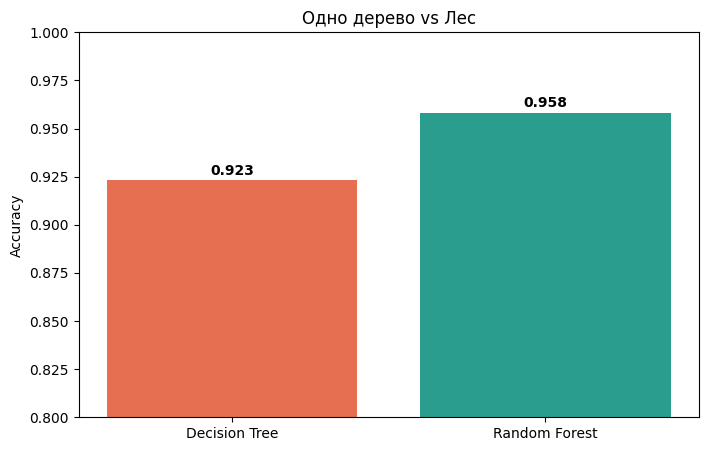

In [18]:
plt.bar(["Decision Tree", "Random Forest"], [dt_acc, rf_acc],
        color=["#e76f51", "#2a9d8f"])
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("Одно дерево vs Лес")
for i, v in enumerate([dt_acc, rf_acc]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center", fontweight="bold")
plt.show()

## 4. Влияние `n_estimators` (количество деревьев)

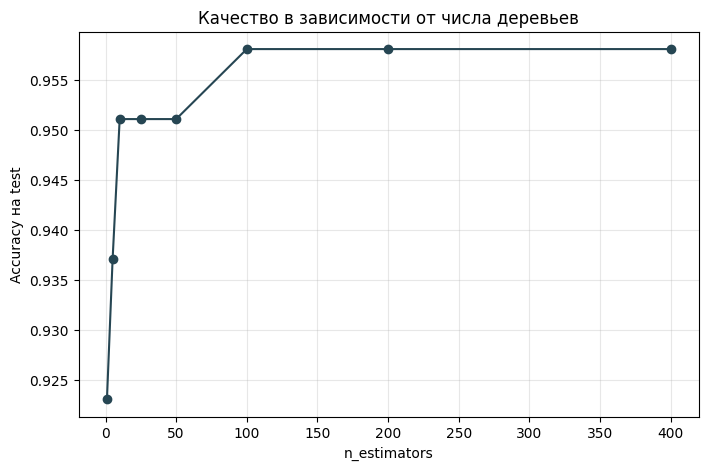

In [19]:
n_values = [1, 5, 10, 25, 50, 100, 200, 400]
acc_by_n = []

for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    acc_by_n.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(n_values, acc_by_n, marker="o", color="#264653")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy на test")
plt.title("Качество в зависимости от числа деревьев")
plt.grid(alpha=0.3)
plt.show()

**Что видим:** один-два дерева работают слабо, после ~50–100 деревьев качество выходит на плато.
Больше деревьев != всегда лучше, но и **не вредит** (только время растёт).

## 5. Влияние `max_depth` (глубина деревьев)

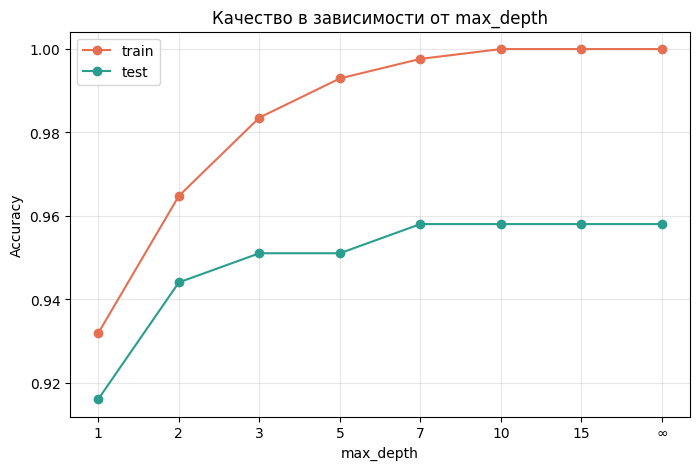

In [20]:
depths = [1, 2, 3, 5, 7, 10, 15, None]
acc_train, acc_test = [], []

for d in depths:
    model = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    acc_train.append(accuracy_score(y_train, model.predict(X_train)))
    acc_test.append(accuracy_score(y_test, model.predict(X_test)))

labels = [str(d) if d is not None else "∞" for d in depths]
x = range(len(depths))

plt.plot(x, acc_train, marker="o", label="train", color="#e76f51")
plt.plot(x, acc_test,  marker="o", label="test",  color="#2a9d8f")
plt.xticks(x, labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Качество в зависимости от max_depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Маленькая глубина → недообучение. Очень большая → дерево запоминает train, но на test прирост уже почти не растёт.

## 6. Метрики классификации

In [21]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1-score":  f1_score(y_test, y_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_proba),
}

pd.DataFrame(metrics, index=["Random Forest"]).T.round(4)

,Random Forest
Accuracy,0.9580
Precision,0.9565
Recall,0.9778
F1-score,0.9670
ROC-AUC,0.9949


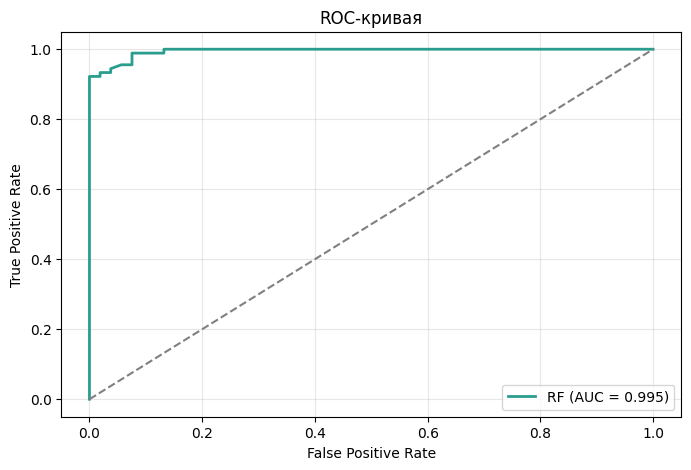

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, color="#2a9d8f", lw=2,
         label=f"RF (AUC = {metrics['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Confusion Matrix

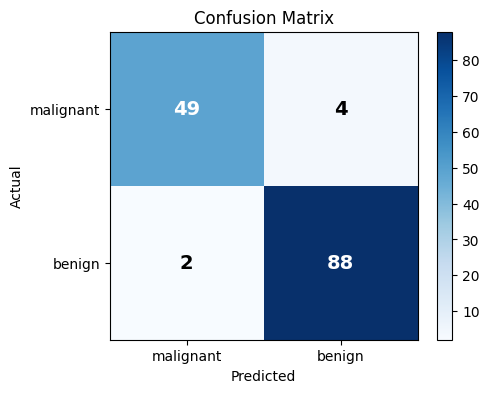

In [23]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["malignant", "benign"])
ax.set_yticklabels(["malignant", "benign"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black",
                fontsize=14, fontweight="bold")
plt.colorbar(im)
plt.show()

## 8. Feature importance

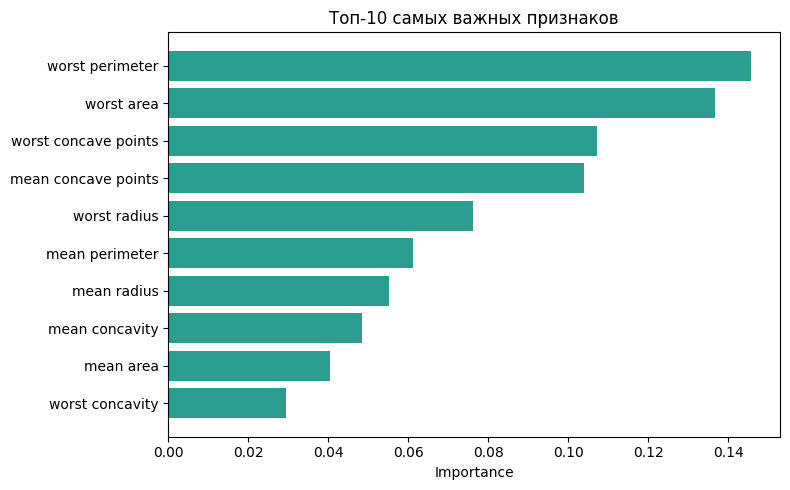

In [24]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top = importances.sort_values(ascending=True).tail(10)

plt.barh(top.index, top.values, color="#2a9d8f")
plt.xlabel("Importance")
plt.title("Топ-10 самых важных признаков")
plt.tight_layout()
plt.show()

## 9. Random Forest для регрессии

Возьмём датасет California Housing — будем предсказывать цену жилья.

In [25]:
housing = fetch_california_housing()
Xr = pd.DataFrame(housing.data, columns=housing.feature_names)
yr = housing.target

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.25, random_state=42
)

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
rf_reg.fit(Xr_train, yr_train)
yr_pred = rf_reg.predict(Xr_test)

mse  = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(yr_test, yr_pred)
r2   = r2_score(yr_test, yr_pred)

pd.DataFrame({
    "MSE":  [mse],
    "RMSE": [rmse],
    "MAE":  [mae],
    "R²":   [r2],
}, index=["RF Regressor"]).round(4)

,MSE,RMSE,MAE,R²
RF Regressor,0.2706,0.5202,0.3456,0.7955


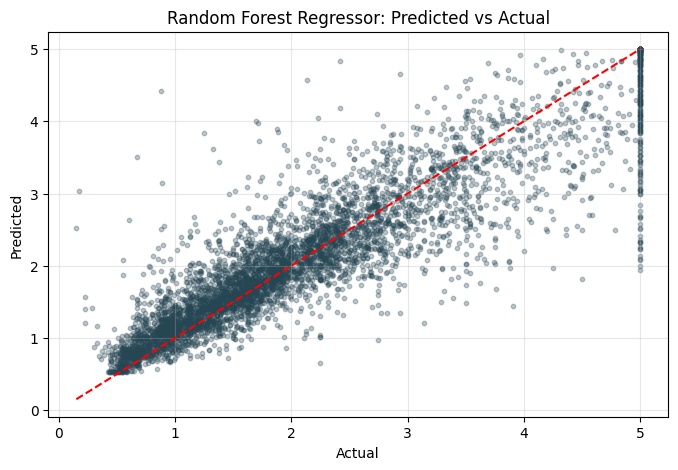

In [26]:
plt.scatter(yr_test, yr_pred, alpha=0.3, s=10, color="#264653")
plt.plot([yr_test.min(), yr_test.max()],
         [yr_test.min(), yr_test.max()], "--", color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Regressor: Predicted vs Actual")
plt.grid(alpha=0.3)
plt.show()

#**Общий итог:**

- Random Forest = много деревьев + голосование.
- Лес обычно **точнее и стабильнее** одного дерева.
- `n_estimators` (количество деревьев): больше — лучше, но с насыщением и `max_depth` (глубина): контролирует переобучение.
- **Feature importance** показывает, какие фичи реально важны.
- Для классификации посмотрели **Accuracy, Precision, Recall, F1, ROC-AUC**.
- Для регрессии — **MSE, RMSE, MAE, R²**.